# **Vorstellung von VS Code „Data Wrangler“ im Kontext eines kleinen Analytics-Use-Cases.**

Yilmaz Kavurgaci  
Modul "Introduction to Business Analytics"  
Mai 2026  
Prof. Dr. Lehmann  
Hochschule der Medien, Stuttgart

---
---

Anhand eines realen Datensatzes aus der Maven-Analytics-Challenge „Turning Bullish“ wird gezeigt, wie Datenaufbereitung, Transformation und Visualisierung mit modernen Data-Wrangling-Tools durchgeführt werden können.

Use Case:

https://mavenanalytics.io/data-drills/turning-bullish

Herausforderung:

https://www.youtube.com/watch?v=FjVSnnFEVs4
* Herausforderer 1: Python 3:33
* Herausforderer 2: Power Bi 4:02
* Herausforderer 3: MySQL 6:07
* Herausforderer 4: Excel 2:38
* Herausforderer 5: Data Wrangler ...

*Hinweis:
</br>Dieses Dokument wird zur Reproduzierbarkeit des Projektes zur Verfügung gestellt.*

---


# 0. Was ist Data Wrangler?

Data Wrangler ist eine kostenlose Erweiterung für Visual Studio Code, die von Microsoft entwickelt wurde und speziell für die interaktive Datenbereinigung und -transformation gedacht ist.

Data Wrangler bietet eine tabellenbasierte, grafische Oberfläche direkt in VS Code, mit der Datensätze erkundet, bereinigt und transformiert werden können – ohne manuell Pandas-Code schreiben zu müssen. Der generierte Code wird dabei automatisch als Python-Skript exportiert oder im Jupyter Notebook direkt verwendet.

## 0.1. Hauptfunktionen
1) Datenexploration

* Vorschau von DataFrames und CSV-Dateien direkt in VS Code
* Übersichtsstatistiken (Mittelwert, Min, Max, fehlende Werte, etc.) pro Spalte
* Visualisierung der Datenverteilung als Histogramme

2) Transformationsoperationen (per Klick)

* Spalten umbenennen, löschen, verschieben
* Datentypen konvertieren (z. B. String → Integer)
* Fehlende Werte behandeln (auffüllen, löschen)
* Duplikate entfernen
* Strings bereinigen (Leerzeichen, Groß-/Kleinschreibung)
* Spalten teilen oder zusammenführen
* Filtern und Sortieren
* Neue Spalten aus Formeln erzeugen

3) Automatische Code-Generierung

* Jede Transformation wird automatisch als Pandas-Code generiert
* Vollständige Nachvollziehbarkeit aller Schritte
* Code kann direkt ins Jupyter Notebook oder Python-Skript exportiert werden

## 0.2. Voraussetzungen

* Visual Studio Code
* Python-Umgebung mit pandas Bibliothek installiert
* Empfohlen: Jupyter-Erweiterung für die Notebook-Integration

---

# Inhalt

Der Fokus liegt darauf zu zeigen, wie effizient sich typische ETL- und Analytics-Aufgaben mit dem Tool umsetzen lassen.

1. Einrichtung der Entwicklungsumgebung
2. Live-Demo der Datenaufbereitung mit dem Data Wrangler
3. Aufbau eines einfachen Data-Mart-/Sternschemas [Zusatz]
4. Reflexion über Herausforderungen, Grenzen und Learnings im Vergleich zu klassischem pandas-/Python-Workflow
---

## 1. Einrichtung der Entwicklungsumgebung

### 1.1. VS Code als Entwicklungsumgebung

https://code.visualstudio.com/download

### 1.2. Download und Installation von Python

![Screenshot 2026-05-05 122731.png](<attachment:Screenshot 2026-05-05 122731.png>)
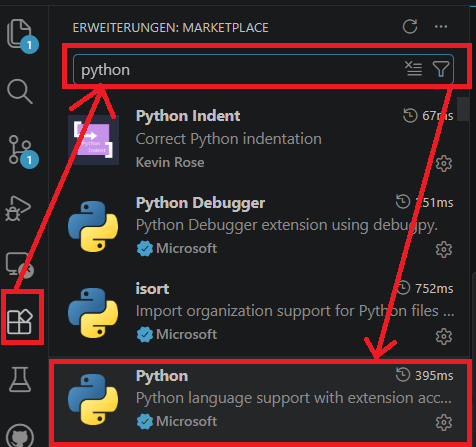

### 1.3. Download und Installation von Jupyter

![Screenshot 2026-05-06 020625.png](<attachment:Screenshot 2026-05-06 020625.png>)
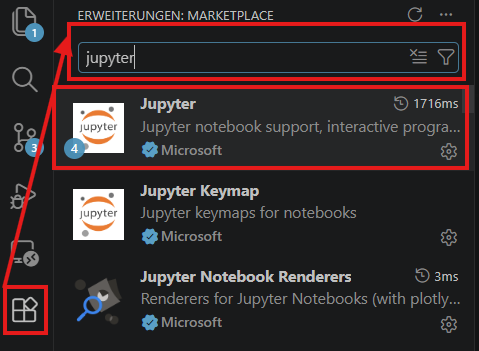

### 1.4. Download und Installation von Data Wrangler
![Screenshot 2026-05-05 124806.png](<attachment:Screenshot 2026-05-05 124806.png>)

Damit die Installationen/Änderungen von VS Code übernommen werden können, genügt ein Neustarten des Programmes. Es kann manchmal nötig sein, die Einstellungen des Data Wranglers anzupassen. Hierfür auf das Zahnradsymbol klicken.
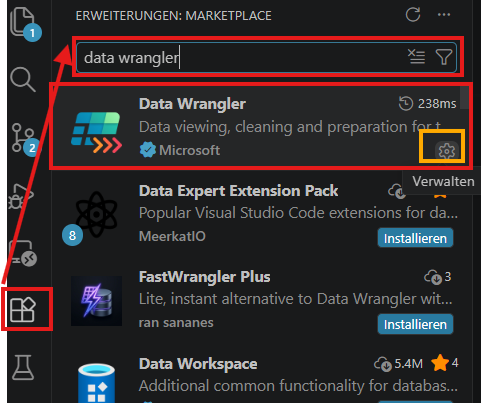

### 1.5. Virtuelle Umgebungen und benötigte Pakete

Eine Python-Umgebung ist im Grunde ein isolierter Ordner mit einer eigenen Python-Installation und eigenen Paketen – so kommt es zu keinen Abhängigkeiten zwischen Projekten.

Virtuelle Umgebungen lösen eines der häufigsten Probleme in Python-Projekten:
* Unterschiedliche Abhängigkeiten
* Inkompatible Paketversionen

Während ältere Projekte häufig auf bestimmte Bibliotheksversionen angewiesen sind, benötigen moderne Anwendungen oft neuere Versionen derselben Pakete. Ohne isolierte Umgebungen würden sich diese Abhängigkeiten gegenseitig beeinflussen und zu Konflikten führen.

Durch virtuelle Umgebungen erhält jedes Projekt:
* Einen eigenen Python-Interpreter
* Eigene installierte Bibliotheken
* Reproduzierbare Entwicklungsbedingungen
* Weniger Konflikte zwischen Projekten

Gerade bei Data-Analytics- und Machine-Learning-Projekten ist dies wichtig, da viele Libraries sehr versionsabhängig sind.

<!DOCTYPE html>
<html lang="de">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Python Umgebungs-Abhängigkeiten</title>
<style>
  * { box-sizing: border-box; margin: 0; padding: 0; }
  body {
    font-family: system-ui, -apple-system, sans-serif;
    background: #f5f4f0;
    display: flex;
    justify-content: center;
    align-items: flex-start;
    padding: 2rem;
    min-height: 100vh;
  }
  .card {
    background: #fff;
    border-radius: 16px;
    padding: 1.5rem;
    box-shadow: 0 2px 12px rgba(0,0,0,0.08);
    max-width: 720px;
    width: 100%;
  }
  h1 {
    font-size: 15px;
    font-weight: 500;
    color: #3d3d3a;
    margin-bottom: 1rem;
  }
  svg text { font-family: system-ui, -apple-system, sans-serif; }

  /* color ramps */
  .c-gray  rect, .c-gray  circle { fill: #F1EFE8; stroke: #5F5E5A; }
  .c-gray  text { fill: #444441; }
  /* Force light background on package rows regardless of VS Code dark theme */
  .pkg rect { fill: #F8F7F3 !important; stroke: #D3D1C7 !important; }
  .pkg text { fill: #444441 !important; }
  .c-teal  rect, .c-teal  circle { fill: #E1F5EE; stroke: #0F6E56; }
  .c-teal  text { fill: #085041; }
  .c-blue  rect, .c-blue  circle { fill: #E6F1FB; stroke: #185FA5; }
  .c-blue  text { fill: #0C447C; }
  .c-purple rect,.c-purple circle { fill: #EEEDFE; stroke: #534AB7; }
  .c-purple text { fill: #3C3489; }
  .c-coral rect, .c-coral circle { fill: #FAECE7; stroke: #993C1D; }
  .c-coral text { fill: #712B13; }

  .arr { fill: none; stroke: #888780; stroke-width: 1.5; }
  .leader { fill: none; stroke: #b4b2a9; stroke-width: 0.5; stroke-dasharray: 3 3; }

  .th { font-size: 14px; font-weight: 500; }
  .ts { font-size: 12px; font-weight: 400; fill: #5F5E5A; }

  .warn  { fill: #BA7517; }
  .ok    { fill: #3B6D11; }
  .muted { fill: #888780; }
</style>
</head>
<body>
<div class="card">
  <h1>Python-Umgebungs-Abhängigkeiten — Projekt A &amp; B</h1>
<svg width="100%" viewBox="0 0 680 540" role="img">
  <title>Abhängigkeitsdarstellung: Projekt A und B mit unterschiedlichen Python-Umgebungen</title>
  <desc>Zwei Projekte mit isolierten virtuellen Umgebungen und unterschiedlichen Paketversionen</desc>
  <defs>
    <marker id="arrow" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse">
      <path d="M2 1L8 5L2 9" fill="none" stroke="context-stroke" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/>
    </marker>
  </defs>

  <!-- System Python -->
  <g>
    <rect x="220" y="20" width="240" height="44" rx="8" fill="#F8F7F3" stroke="#D3D1C7" stroke-width="0.5"/>
    <text class="th" x="340" y="38" text-anchor="middle" dominant-baseline="central" fill="#444441">System Python</text>
    <text class="ts" x="340" y="55" text-anchor="middle" dominant-baseline="central" fill="#5F5E5A">z. B. Python 3.12</text>
  </g>

  <!-- Arrows to venvs -->
  <line x1="300" y1="64" x2="180" y2="130" class="arr" stroke="#888780" stroke-dasharray="5 4" marker-end="url(#arrow)"/>
  <line x1="380" y1="64" x2="500" y2="130" class="arr" stroke="#888780" stroke-dasharray="5 4" marker-end="url(#arrow)"/>

  <!-- venv A -->
  <g class="c-teal">
    <rect x="30" y="130" width="280" height="340" rx="14" stroke-width="0.5"/>
    <text class="th" x="170" y="155" text-anchor="middle" dominant-baseline="central">venv A</text>
    <text class="ts" x="170" y="172" text-anchor="middle" dominant-baseline="central">Python 3.10</text>
  </g>
  <g class="c-purple">
    <rect x="55" y="185" width="230" height="44" rx="8" stroke-width="0.5"/>
    <text class="th" x="170" y="203" text-anchor="middle" dominant-baseline="central">Projekt A</text>
    <text class="ts" x="170" y="220" text-anchor="middle" dominant-baseline="central">Legacy-ML-Pipeline</text>
  </g>
  <g>
    <rect x="55" y="244" width="230" height="36" rx="6" fill="#F8F7F3" stroke="#D3D1C7" stroke-width="0.5"/>
    <text class="ts" x="75" y="267" dominant-baseline="central" fill="#444441">pandas</text>
    <text class="ts warn" x="270" y="267" text-anchor="end" dominant-baseline="central">2.1.4</text>
  </g>
  <g>
    <rect x="55" y="288" width="230" height="36" rx="6" fill="#F8F7F3" stroke="#D3D1C7" stroke-width="0.5"/>
    <text class="ts" x="75" y="311" dominant-baseline="central" fill="#444441">numpy</text>
    <text class="ts warn" x="270" y="311" text-anchor="end" dominant-baseline="central">1.24.0</text>
  </g>
  <g>
    <rect x="55" y="332" width="230" height="36" rx="6" fill="#F8F7F3" stroke="#D3D1C7" stroke-width="0.5"/>
    <text class="ts" x="75" y="355" dominant-baseline="central" fill="#444441">scikit-learn</text>
    <text class="ts warn" x="270" y="355" text-anchor="end" dominant-baseline="central">1.2.2</text>
  </g>
  <g>
    <rect x="55" y="376" width="230" height="36" rx="6" fill="#F8F7F3" stroke="#D3D1C7" stroke-width="0.5"/>
    <text class="ts" x="75" y="399" dominant-baseline="central" fill="#444441">tensorflow</text>
    <text class="ts warn" x="270" y="399" text-anchor="end" dominant-baseline="central">2.12.0</text>
  </g>
  <g>
    <rect x="55" y="420" width="230" height="36" rx="6" fill="#F8F7F3" stroke="#D3D1C7" stroke-width="0.5"/>
    <text class="ts" x="75" y="443" dominant-baseline="central" fill="#444441">requests</text>
    <text class="ts warn" x="270" y="443" text-anchor="end" dominant-baseline="central">2.28.0</text>
  </g>

  <!-- venv B -->
  <g class="c-blue">
    <rect x="370" y="130" width="280" height="340" rx="14" stroke-width="0.5"/>
    <text class="th" x="510" y="155" text-anchor="middle" dominant-baseline="central">venv B</text>
    <text class="ts" x="510" y="172" text-anchor="middle" dominant-baseline="central">Python 3.12</text>
  </g>
  <g class="c-coral">
    <rect x="395" y="185" width="230" height="44" rx="8" stroke-width="0.5"/>
    <text class="th" x="510" y="203" text-anchor="middle" dominant-baseline="central">Projekt B</text>
    <text class="ts" x="510" y="220" text-anchor="middle" dominant-baseline="central">Moderne API-Anwendung</text>
  </g>
  <g>
    <rect x="395" y="244" width="230" height="36" rx="6" fill="#F8F7F3" stroke="#D3D1C7" stroke-width="0.5"/>
    <text class="ts" x="415" y="267" dominant-baseline="central" fill="#444441">pandas</text>
    <text class="ts ok" x="610" y="267" text-anchor="end" dominant-baseline="central">3.0.2</text>
  </g>
  <g>
    <rect x="395" y="288" width="230" height="36" rx="6" fill="#F8F7F3" stroke="#D3D1C7" stroke-width="0.5"/>
    <text class="ts" x="415" y="311" dominant-baseline="central" fill="#444441">numpy</text>
    <text class="ts ok" x="610" y="311" text-anchor="end" dominant-baseline="central">2.0.1</text>
  </g>
  <g>
    <rect x="395" y="332" width="230" height="36" rx="6" fill="#F8F7F3" stroke="#D3D1C7" stroke-width="0.5"/>
    <text class="ts" x="415" y="355" dominant-baseline="central" fill="#444441">fastapi</text>
    <text class="ts ok" x="610" y="355" text-anchor="end" dominant-baseline="central">0.115.0</text>
  </g>
  <g>
    <rect x="395" y="376" width="230" height="36" rx="6" fill="#F8F7F3" stroke="#D3D1C7" stroke-width="0.5"/>
    <text class="ts" x="415" y="399" dominant-baseline="central" fill="#444441">pydantic</text>
    <text class="ts ok" x="610" y="399" text-anchor="end" dominant-baseline="central">2.7.0</text>
  </g>
  <g>
    <rect x="395" y="420" width="230" height="36" rx="6" fill="#F8F7F3" stroke="#D3D1C7" stroke-width="0.5"/>
    <text class="ts" x="415" y="443" dominant-baseline="central" fill="#444441">requests</text>
    <text class="ts ok" x="610" y="443" text-anchor="end" dominant-baseline="central">2.32.0</text>
  </g>

  <!-- Conflict indicators -->
  <line x1="313" y1="267" x2="393" y2="267" stroke="#b4b2a9" stroke-width="1" stroke-dasharray="3 3"/>
  <line x1="313" y1="311" x2="393" y2="311" stroke="#b4b2a9" stroke-width="1" stroke-dasharray="3 3"/>
  <line x1="313" y1="443" x2="393" y2="443" stroke="#b4b2a9" stroke-width="1" stroke-dasharray="3 3"/>
  <text class="ts muted" x="340" y="261" text-anchor="middle" dominant-baseline="central">≠</text>
  <text class="ts muted" x="340" y="305" text-anchor="middle" dominant-baseline="central">≠</text>
  <text class="ts muted" x="340" y="437" text-anchor="middle" dominant-baseline="central">≠</text>

  <!-- Legend -->
  <line x1="30" y1="500" x2="60" y2="500" stroke="#b4b2a9" stroke-width="1" stroke-dasharray="3 3"/>
  <text class="ts muted" x="70" y="494" dominant-baseline="central">≠</text>
  <text class="ts" x="85" y="500" dominant-baseline="central">gleiche Bibliothek, unterschiedliche Version</text>
  <line x1="30" y1="522" x2="58" y2="522" stroke="#888780" stroke-width="1" stroke-dasharray="5 4" marker-end="url(#arrow)"/>
  <text class="ts" x="66" y="522" dominant-baseline="central">erbt Python-Interpreter</text>
</svg>
</div>
</body>
</html>

#### 1.5.1. Vorgehensweise für eine mögliche Einrichtung einer Umgebung:

Voraussetzungen:
* Anaconda oder Miniconda installiert (https://www.anaconda.com/download)
* Terminal / Eingabeaufforderung (Windows: PowerShell oder Anaconda Prompt)
* conda ist in der PATH-Variable registriert

Einrichtung der Umgebung erfolgt über Befehle in bash:

1. Neue Umgebung erstellen
```bash
conda create --name modul_vier python=3.13.5
```
2. Umgebung aktivieren
```bash
conda activate modul_vier
```
3. Pakete installieren
```bash
conda install pandas matplotlib
# oder mit pip:
pip install paketname
```
4. Jupyter-Kernel registrieren (für VS Code / Jupyter)
```bash
pip install ipykernel
python -m ipykernel install --user --name=modul_vier --display-name "Modul Vier"
```
Nach dem Erstellen der Umgebung in VS Code:
Strg+Shift+P → "Python: Interpreter auswählen" → die neu erstellte Umgebung auswählen.

<details>
<summary>Weitere nützliche Befehle (klick mich)</summary>

5. Umgebung deaktivieren
```bash
conda deactivate
```
6. Alle Umgebungen anzeigen
```bash
conda env list
```
7. Umgebung löschen
```bash
conda remove --name meine_umgebung --all
```
8. Umgebung exportieren (für andere reproduzierbar machen)
```bash
conda env export > environment.yml
```
9. Umgebung aus Datei wiederherstellen
```bash
conda env create -f environment.yml
```
</details>

## 1.6. Jupyter Notebook und Wahl des Kernels

**Jupyter Notebook Datei anlegen**

Datei > Neue Datei..

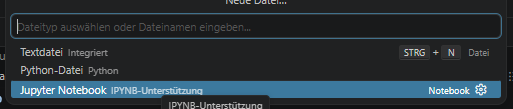

**Was ist ein Kernel?**


Ein Kernel ist der Ausführungsprozess im Hintergrund – er empfängt den Code, führt ihn aus und gibt das Ergebnis zurück. Jeder Kernel ist an eine bestimmte Python-Installation gebunden.
In Jupyter Notebooks innerhalb von VS Code wird ein Kernel ausgewählt, weil dieser bestimmt, welche Python-Umgebung den Code ausführt.

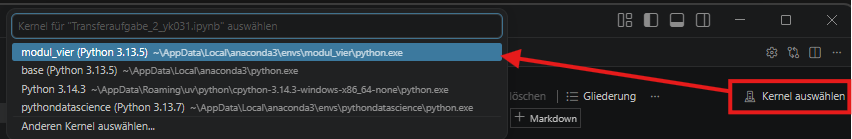

---

# 2. Live-Demo der Datenaufbereitung mit dem Data Wrangler

## 2.1. Der Datensatz:

Schlusskurs der letzten 5 Jahre des SPDR S&P 500 ETF Trust (SPY)

## 2.2. Die Aufgabe:

Den 50-Tage- und 200-Tage-gleitenden Durchschnitt basierend auf dem Schlusskurs zu berechnen und jeden „Golden Cross"-Moment zu identifizieren – also wenn der kurzfristige Durchschnitt (50-Tage) den langfristigen Durchschnitt (200-Tage) von unten nach oben kreuzt – was einen potenziellen Bullenmarkt signalisiert.

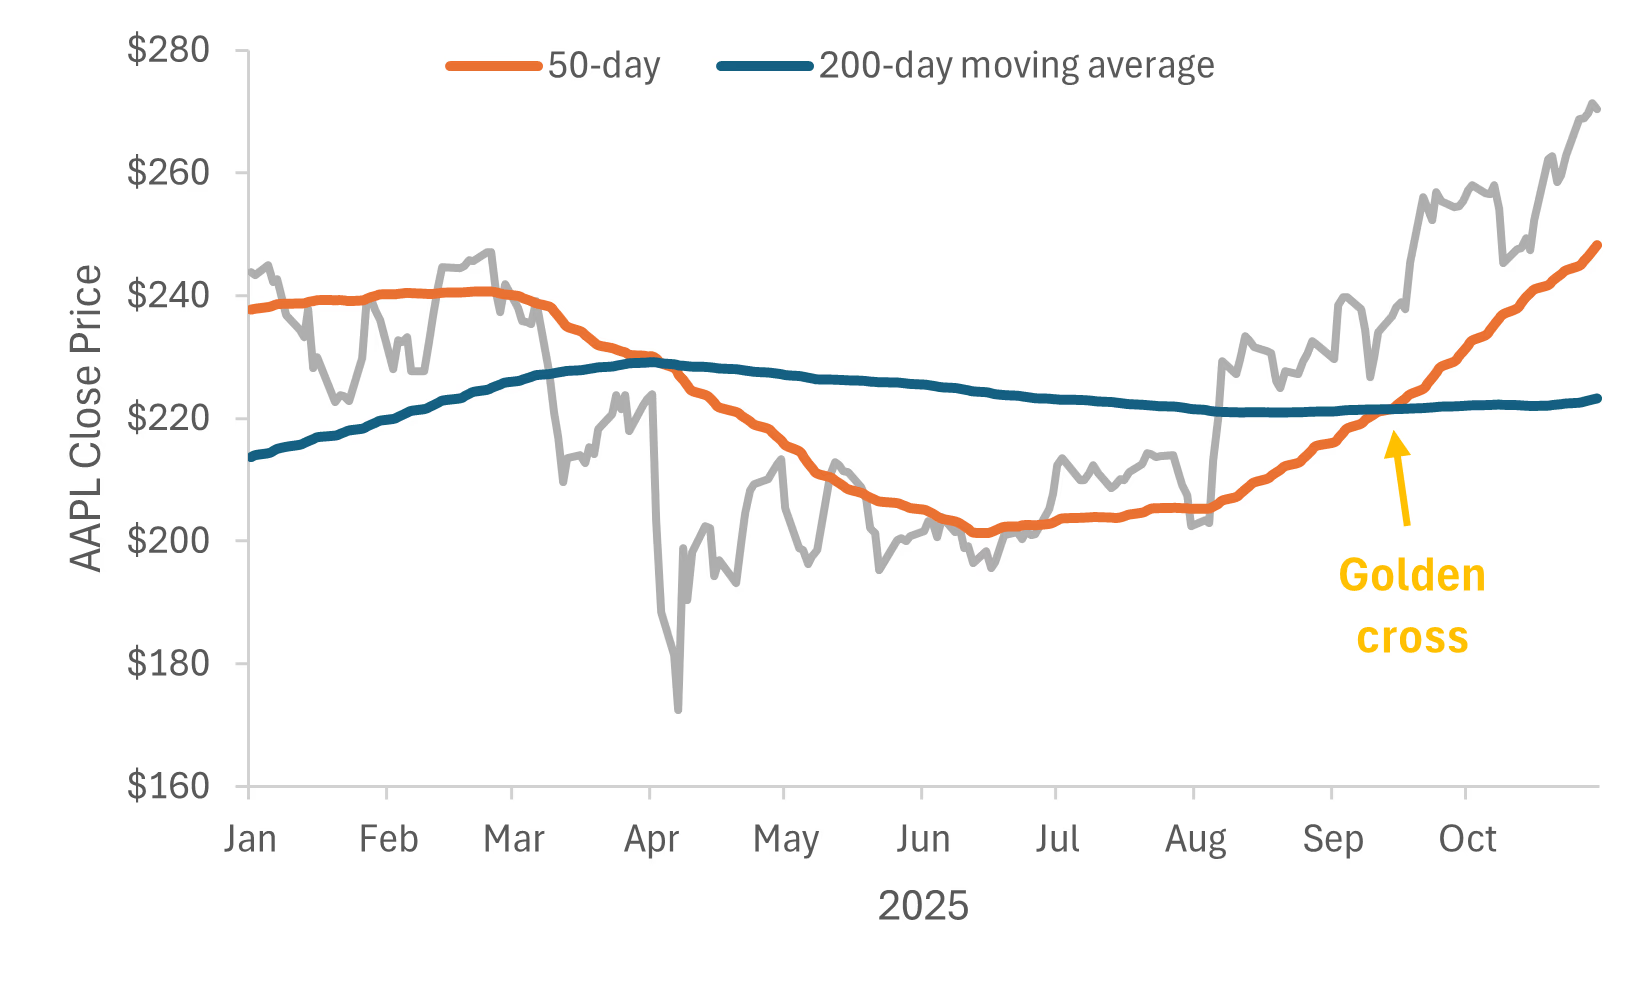


## 2.3. Explizit:

Um die Übung abzuschließen, erstelle eine Tabelle mit dem Datum, dem Schlusskurs und drei neuen Spalten:

* 50-Tage gleitender Durchschnitt: Der durchschnittliche Schlusskurs der letzten 50 Handelstage, berechnet für jedes Datum
* 200-Tage gleitender Durchschnitt: Der durchschnittliche Schlusskurs der letzten 200 Handelstage, berechnet für jedes Datum
* Golden Cross: Ein binäres Feld (1/0), das nur an dem genauen Datum den Wert 1 annimmt, an dem der 50-Tage-Durchschnitt den 200-Tage-Durchschnitt von unten nach oben kreuzt; andernfalls 0

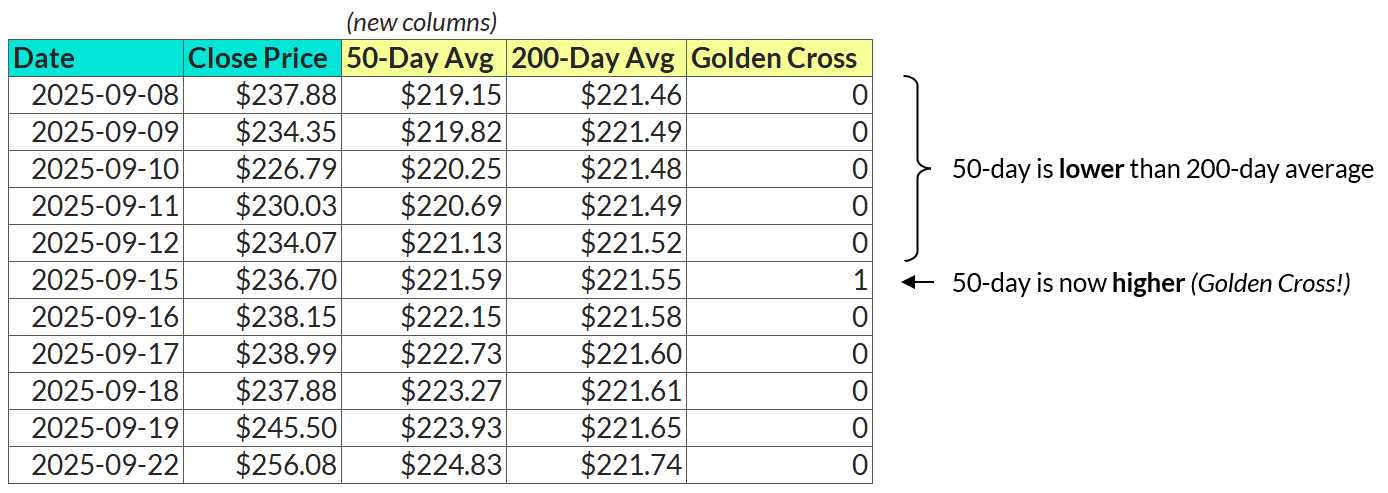

## 2.4. Lösung einreichen
Was war der Schlusskurs am Datum des letzten „Golden Cross"? (nur Zahlen, keine Währungssymbole)

![Screenshot 2026-05-06 034727.png](<attachment:Screenshot 2026-05-06 034727.png>)
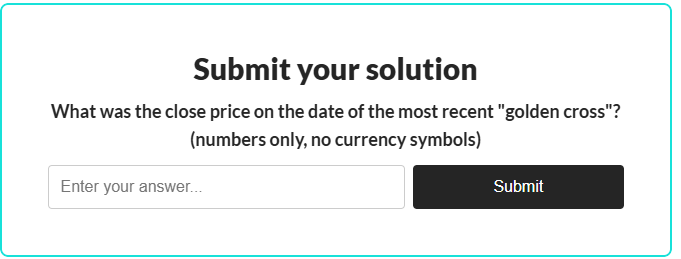

## 2.5. Live generierter Code

In [ ]:
# pip install pandas

In [ ]:
import pandas as pd

def clean_data(df):
    # Spalte 'ma_50' wurde aus der Formel erstellt.
    df['ma_50'] = df["Close"].rolling(50).mean()
    # Spalte 'ma_200' wurde aus der Formel erstellt.
    df['ma_200'] = df["Close"].rolling(200).mean()
    # Spalte 'golden_cross' wurde aus der Formel erstellt.
    df['golden_cross'] = ((df['ma_50'] > df['ma_200']) & (df['ma_50'].shift(1) <= df['ma_200'].shift(1))).astype(int)
    # Zeilen basierend auf Spalte filtern: 'golden_cross'
    df = df[df['golden_cross'] == 1]
    return df

# Die Variable „df“ wurde aus dem URI geladen: c:\Users\YilmazKavurgaci\OneDrive - Deutsche Bahn\Studium\2. Semester\Introduction to Business Analytics\Transferaufgabe\Introduction_to_Business_Analytics\SPY_close_price_5Y.csv
df = pd.read_csv(r'c:\Users\YilmazKavurgaci\OneDrive - Deutsche Bahn\Studium\2. Semester\Introduction to Business Analytics\Transferaufgabe\Introduction_to_Business_Analytics\SPY_close_price_5Y.csv')

df_clean = clean_data(df.copy())
df_clean.head()

,Date,Close,ma_50,ma_200,golden_cross
566,2023-02-02,416.78,394.3504,394.25025,1
1169,2025-07-01,617.65,583.0978,582.04155,1


## 2.6. Konventionelle Datenmanipulation

0. Bibliotheken installieren

In [ ]:
# pip install matplotlib

1. Bibliotheken importieren

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

2. Daten laden & ersten Überblick verschaffen

    Die CSV-Datei wird mit parse_dates eingelesen, damit die Datumsspalte sofort als datetime-Typ vorliegt. Anschließend erfolgt eine chronologische Sortierung und die Datenqualität wird geprüft.

In [2]:
# Pfad ggf. anpassen
PATH = r'SPY_close_price_5Y.csv'

df = pd.read_csv(PATH, parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Überblick
print(df.shape)
df.head()

(1256, 2)


,Date,Close
0,2020-11-02,330.20
1,2020-11-03,336.03
2,2020-11-04,343.54
3,2020-11-05,350.24
4,2020-11-06,350.16


In [3]:
# Fehlende Werte prüfen
print(df.isnull().sum())
print(df.dtypes)

Date     0
Close    0
dtype: int64
Date     datetime64[us]
Close           float64
dtype: object


3. Feature Engineering — Gleitende Durchschnitte

    Die Rolling-Windows werden direkt auf die Close-Spalte angewendet. Die ersten 199 Zeilen enthalten für ma_200 NaN-Werte — das ist korrekt und wird bewusst beibehalten.

In [4]:
df['ma_50']  = df['Close'].rolling(window=50).mean()
df['ma_200'] = df['Close'].rolling(window=200).mean()

# Kontrolle: Anzahl gültiger Werte
print(f"Gültige ma_50:  {df['ma_50'].notna().sum()}")
print(f"Gültige ma_200: {df['ma_200'].notna().sum()}")

Gültige ma_50:  1207
Gültige ma_200: 1057


4. Signal-Erkennung — Golden Cross
    
    Ein Golden Cross liegt vor, wenn:
    
    * ma_50 heute größer als ma_200 ist, und
    * ma_50 gestern noch kleiner oder gleich ma_200 war.
    
    Die `.shift(1)`-Methode verschiebt die Serie um einen Tag zurück. Mit `.astype(int)` ergibt sich 1 für Wahr, 0 für Falsch.

In [5]:
above_today     = df['ma_50'] > df['ma_200']
above_yesterday = df['ma_50'].shift(1) <= df['ma_200'].shift(1)

df['golden_cross'] = (above_today & above_yesterday).astype(int)

# Anzahl Signale im Beobachtungszeitraum
n_signals = df['golden_cross'].sum()
print(f"Anzahl Golden-Cross-Signale: {n_signals}")

Anzahl Golden-Cross-Signale: 2


5. Signaltage extrahieren
    
    Aus dem vollständigen DataFrame werden nur die Tage herausgefiltert, an denen ein Golden Cross aufgetreten ist — analog zur Data-Wrangler-Ausgabe, aber mit klarer Trennung von Original- und gefilterter Ansicht.  

In [6]:
# Original-DataFrame bleibt erhalten!
df_signals = df[df['golden_cross'] == 1][[
    'Date', 'Close', 'ma_50', 'ma_200'
]].reset_index(drop=True)

df_signals

# df

,Date,Close,ma_50,ma_200
0,2023-02-02,416.78,394.3504,394.25025
1,2025-07-01,617.65,583.0978,582.04155


6. Visualisierung
    
    Der Kursverlauf, beide gleitenden Durchschnitte und alle Golden-Cross-Signale werden in einem einzigen Plot dargestellt. Signale werden als vertikale Markierungen eingezeichnet.

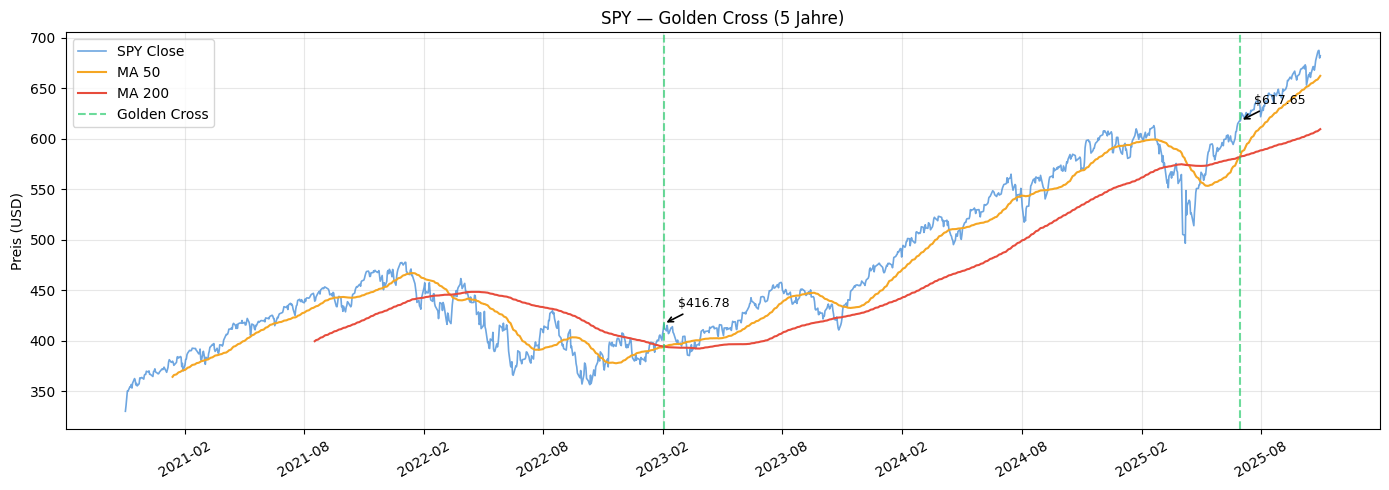

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['Date'], df['Close'],
        label='SPY Close', color='#4A90D9', linewidth=1.2, alpha=0.8)
ax.plot(df['Date'], df['ma_50'],
        label='MA 50',    color='#F5A623', linewidth=1.5)
ax.plot(df['Date'], df['ma_200'],
        label='MA 200',   color='#E74C3C', linewidth=1.5)

# Signale einzeichnen + Preis annotieren
for i, row in df_signals.iterrows():
    ax.axvline(row['Date'], color='#2ECC71',
               alpha=0.7, linewidth=1.5, linestyle='--',
               label='Golden Cross' if i == 0 else "")
    ax.annotate(f"${row['Close']:.2f}",
                xy=(row['Date'], row['Close']),
                xytext=(10, 12),
                textcoords='offset points',
                fontsize=9,
                color="#000000",
                arrowprops=dict(arrowstyle='->', color="#000000", lw=1.2))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30)
ax.set_title('SPY — Golden Cross (5 Jahre)')
ax.set_ylabel('Preis (USD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Vergleich: Konventionell vs. Data Wrangler

| | **Konventionell** | **Data Wrangler** |
|---|---|---|
| **Stärken** | ✅ Vollständige Nachvollziehbarkeit — jeder Schritt dokumentiert | ✅ Schnelle, visuelle Exploration ohne Codekenntnis |
| | ✅ Originaldaten bleiben erhalten (`df` wird nicht überschrieben) | ✅ Automatische Code-Generierung reduziert Tippfehler |
| | ✅ Fehlerkontrolle (`isnull`, `dtypes`) explizit eingebaut | ✅ Gut für initiale Datensichtung und einfache Transformationen |
| | ✅ Visualisierung direkt integriert — kein Tool-Wechsel nötig | |
| | ✅ Modularer, wiederverwendbarer Code ohne versteckte Abhängigkeiten | |
| **Schwächen** | ❌ Mehr Schreibaufwand, besonders für Exploration und Prototyping | ❌ Generierter Code mutiert `df` direkt — kein Original erhalten |
| | ❌ Kein visuelles GUI — Fehler ohne Erfahrung schwerer erkennbar | ❌ Kein Fehlerhandling oder Qualitätsprüfungen enthalten |
| | | ❌ Hardcodierter Dateipfad — nicht portierbar auf andere Systeme |
| | | ❌ `clean_data` mischt Transformation & Filter — verletzt Single-Responsibility |
| | | ❌ Keine Visualisierung — reiner Transformations-Output |

---

# 3. Aufbau eines einfachen Data-Mart-/Sternschemas

Ein Sternschema (Star Schema) ist ein einfaches relationales Datenbankmodell aus dem Data-Warehouse-Design. Es besteht aus einer zentralen **Fact-Tabelle**, die messbare Kennzahlen enthält, und mehreren **Dimensionstabellen**, die den beschreibenden Kontext liefern.

Das Grundprinzip: Kennzahlen und Kontext werden bewusst getrennt. Die Fact-Tabelle ist schlank und enthält nur Zahlen sowie Fremdschlüssel. Die Dimensionen liefern alles Beschreibende – Datum, Zeit, Produkt, Standort etc.

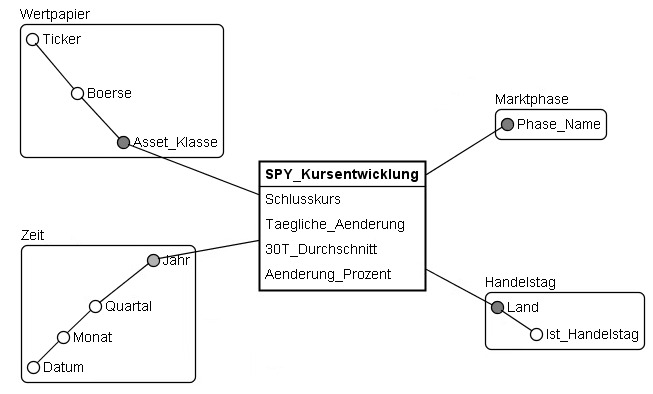

## 3.1. Anwendung auf den SPY-Use-Case

Das erweiterte Schema besteht aus **fünf Tabellen** und folgt dem Sternschema-Prinzip mit einer zentralen Fact-Tabelle und vier spezialisierten Dimensionen:

**`F_SPY_KURSENTWICKLUNG`** (Fact-Tabelle)  
Zentrale Kennzahltabelle mit einer Zeile pro Handelstag. Enthält:
- **Fremdschlüssel:** ID_WERTPAPIER, ID_ZEIT, ID_HANDELSTAG, ID_MARKTPHASE
- **Kennzahlen:** SCHLUSSKURS, TÄGLICHE_ÄNDERUNG, 30T_DURCHSCHNITT, ÄNDERUNG_PROZENT

Die Fact-Tabelle bleibt schlank und enthält nur messbare Größen sowie Verweise auf Dimensionen.

**`D_WERTPAPIER`** (Wertpapier-Dimension)  
Stammdaten des Finanzinstruments:
- TICKER (z.B. "SPY")
- ASSET_KLASSE (z.B. "ETF")
- BOERSE (z.B. "NYSE")

Erlaubt einfache Erweiterung auf weitere Wertpapiere ohne Schema-Änderung.

**`D_ZEIT`** (Zeitdimension)  
Hierarchischer Kalender für Zeitreihen-Analysen:
- DATUM (das genaue Handelsdatum)
- MONAT, QUARTAL, JAHR
- Basis für Aggregationen nach Zeitperioden

**`D_HANDELSTAG`** (Handelstag-Dimension)  
Metadaten zu Handelscharakteristiken:
- IST_HANDELSTAG (0/1 Flag: war es ein echter Handelstag?)
- LAND (länderspezifische Feiertage)

Trennt Kalender-Logik von Markt-Logik.

**`D_MARKTPHASE`** (Marktphasen-Dimension)  
Klassifizierung von Marktregimen:
- PHASE_NAME (z.B. "Bullenmarkt", "Bärenmarkt", "Konsolidierung")

Ermöglicht einfache Filterung und Vergleich von Marktphasen ohne hardcodierte Schwellwerte.

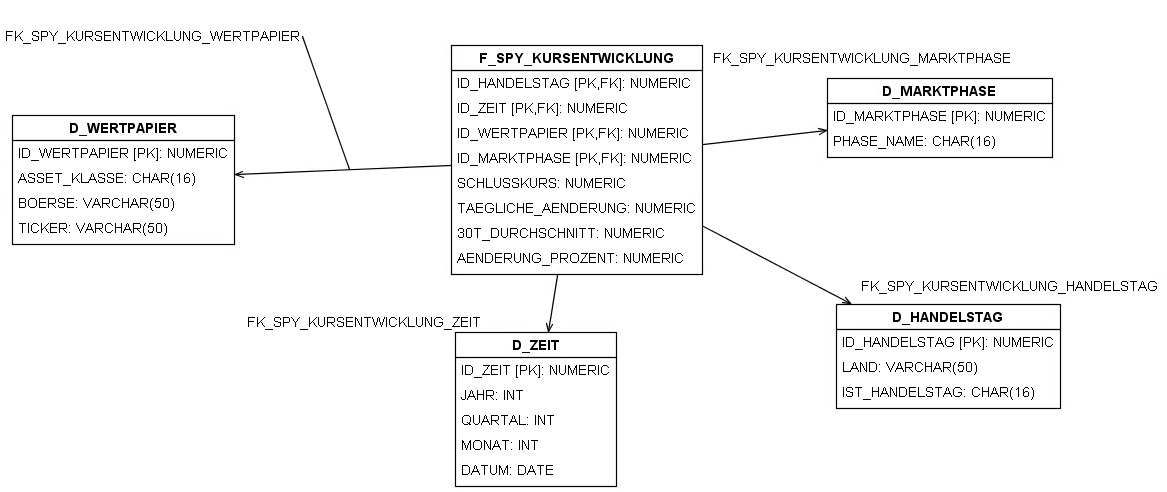

## 3.2. Vorteile des Sternschemas

| Eigenschaft | Erklärung |
|---|---|
| **Erweiterbarkeit** | Weitere Wertpapiere lassen sich durch neue Zeilen in `dim_stock` ergänzen – ohne Strukturänderung |
| **Analysierbarkeit** | Abfragen nach Zeitraum, Monat oder Wochentag sind direkt über `dim_date` möglich |
| **Trennung von Verantwortlichkeiten** | Kennzahlen (Fact) und Beschreibung (Dimension) bleiben sauber getrennt |
| **Kompatibilität** | Das Modell ist direkt in SQL, pandas oder BI-Tools wie Power BI verwendbar |
---

# 4. Reflexion über Herausforderungen, Grenzen und Learnings im Vergleich zu klassischem pandas-/Python-Workflow

## 4.1. Herausforderungen

**Hardcodierter Dateipfad**  
Der von Data Wrangler generierte Code enthält den lokalen Systempfad. Auf jedem anderen Rechner bricht die Ausführung sofort ab. Lösung: relativer Pfad oder `pathlib`.

```python
# Generiert (nicht portierbar)
df = pd.read_csv(r'C:\Users\YilmazKavurgaci\...\SPY_close_price_5Y.csv')

# Besser
from pathlib import Path
df = pd.read_csv(Path(__file__).parent / 'SPY_close_price_5Y.csv')
```

**DataFrame wird direkt mutiert**  
Data Wrangler überschreibt den Original-DataFrame innerhalb der `clean_data`-Funktion. Wer das nicht bemerkt, verliert seine Ausgangsdaten. Konventionell arbeitet man immer mit einer expliziten Kopie.

```python
# Generiert (mutiert df direkt)
def clean_data(df):
    df['ma_50'] = df["Close"].rolling(50).mean()
    ...

# Besser
df_clean = clean_data(df.copy())
```

**Transformation und Filter in einer Funktion**  
Der generierte Code mischt Feature Engineering (gleitende Durchschnitte berechnen) und Filterung (nur Golden-Cross-Tage behalten) in `clean_data`. Das verletzt das Single-Responsibility-Prinzip und erschwert spätere Wiederverwendung oder Tests.

**Kernel-Konfiguration**  
Wer die virtuelle Umgebung nicht korrekt als Jupyter-Kernel registriert, erhält `ModuleNotFoundError` – und sucht oft lange nach der Ursache, obwohl das Paket bereits installiert ist.

## 4.2. Key Learnings

**Data Wrangler ist ein Einstiegswerkzeug, kein Ersatz**  
Das Tool eignet sich hervorragend für schnelle Datenexploration und einfache Transformationen. Sobald der Code reproduzierbar, portierbar oder testbar sein soll, muss der generierte Output nachbearbeitet werden.

**Generierten Code immer lesen, nie blind übernehmen**  
Data Wrangler schreibt funktionierenden, aber nicht zwingend guten Code. Den Output als Lernmaterial zu nutzen – wie funktioniert `rolling()`? wie funktioniert `shift()`? – ist der eigentliche Mehrwert für Einsteiger.

**Virtuelle Umgebungen von Anfang an einrichten**  
Nicht erst wenn Konflikte entstehen. Der Einrichtungsaufwand ist einmalig, der Nutzen dauerhaft: saubere Abhängigkeiten, reproduzierbare Ergebnisse, keine Versionskonflikte zwischen Projekten.

**Original-DataFrame nie überschreiben**  
Immer mit `df.copy()` arbeiten und Transformationen auf der Kopie durchführen. Das ist eine Gewohnheit, die man früh entwickeln sollte – sie verhindert schwer nachvollziehbare Seiteneffekte.

**Visualisierung gehört zum Workflow**  
Data Wrangler liefert ausschließlich Tabellen. Erst durch den Plot wird sichtbar, ob ein Signal sinnvoll ist oder auf einem Fehler basiert. Analyse ohne Visualisierung ist blind.

## 4.3. Zusammenfassender Vergleich und Fazit

Stärken
* Kein manuelles Coding nötig
* Generierter Code ist sauber & nachvollziehbar
* Direkt in VS Code integriert
* Kostenlos

Schwächen
* Nur für pandas/Python
* Begrenzte Visualisierungen
* Keine Datenbankanbindung
* Große Datensätze können langsam werden

Fazit
Data Wrangler ist ideal für Datenwissenschaftler und Analysten, die schnell Daten explorieren und bereinigen wollen, ohne jede Transformation von Hand zu coden. Besonders nützlich ist es als Lernwerkzeug, da man den generierten Pandas-Code direkt studieren und verstehen kann.